### Data Quality Assessment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)

\Loading the data

In [2]:
df = pd.read_csv(r'C:\NG\Hospital Readmission Risk Prediction\Data\Raw\hospital_readmission_dataset.csv')

In [3]:
df.head()

,patient_id,patient_age,gender,marital_status,admission_type,department,diagnosis,secondary_diagnosis,blood_pressure,glucose_level,...,doctor_rating,followup_compliance_score,hospital_bill_amount,admission_date,discharge_date,followup_date,readmission_notice_sent,readmission_confirmed,final_readmission_reason,readmitted
0,PAT0000000,69,Female,Single,Elective,Orthopedics,Diabetes,NaN,119,227.0,...,10.0,43.0,₹125345,2024-11-12,2024-10-31,2026-11-20,No,Yes,NaN,1
1,PAT0000001,32,Male,Married,Emergency,Neurology,Asthma,Kidney Disease,122,100.0,...,1.0,94.0,26391.0,2024-12-28,2025-05-15,2026-11-14,Yes,Yes,Infection,1
2,PAT0000002,89,Male,Divorced,Urgent,General Medicine,Hypertension,Kidney Disease,90,237.0,...,4.0,18.0,NaN,2023-10-12,2023-06-25,2026-07-13,Yes,Yes,Medication Issue,1
3,PAT0000003,78,Male,Single,Elective,Pulmonology,Infection,NaN,127,NaN,...,10.0,12.0,61112.0,2025-07-27,2025-05-02,07-26-2026,No,No,NaN,1
4,PAT0000004,38,male,Single,Elective,Neurology,Asthma,Diabetes,92,74.0,...,4.0,NaN,NaN,2023-11-15,2026-01-29,2026-07-22,No,No,Medication Issue,1


\ Missing Value Analysis 

In [4]:
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count'  : missing_count,
    'Missing %'      : missing_pct.round(2),
    'Present Count'  : df.notnull().sum(),
    'Data Type'      : df.dtypes
}).sort_values('Missing %', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]

print("=== MISSING VALUE REPORT ===\n")
print(missing_df.to_string())

=== MISSING VALUE REPORT ===

                           Missing Count  Missing %  Present Count Data Type
secondary_diagnosis                12716      25.18          37784       str
final_readmission_reason            9995      19.79          40505       str
doctor_rating                       7580      15.01          42920   float64
glucose_level                       7582      15.01          42918   float64
followup_compliance_score           7547      14.94          42953   float64
hospital_bill_amount                6501      12.87          43999       str


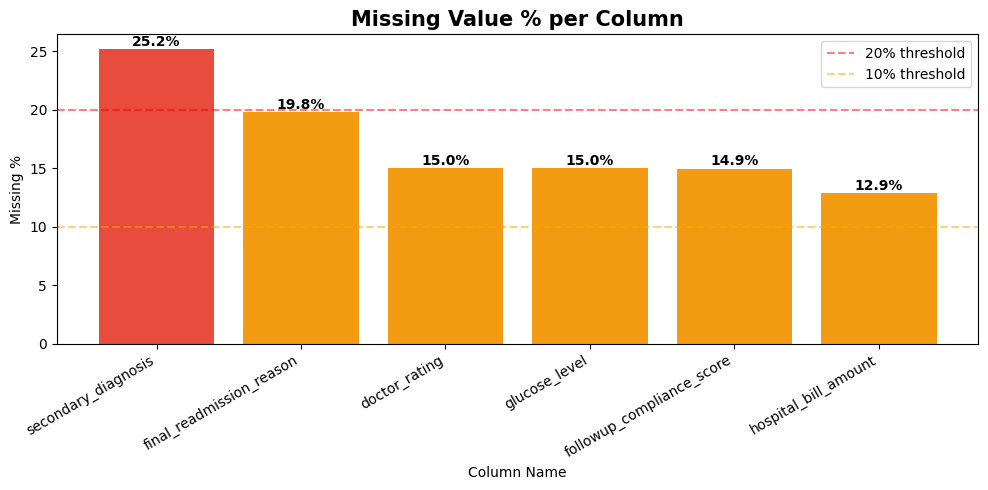

In [5]:
plt.figure(figsize=(10, 5))
bars = plt.bar(missing_df.index,
               missing_df['Missing %'],
               color=['#e74c3c' if x > 20 else '#f39c12' if x > 10 else '#3498db'
                      for x in missing_df['Missing %']])

for bar, pct in zip(bars, missing_df['Missing %']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{pct:.1f}%',
             ha='center', fontweight='bold', fontsize=10)

plt.title('Missing Value % per Column', fontsize=15, fontweight='bold')
plt.xlabel('Column Name')
plt.ylabel('Missing %')
plt.xticks(rotation=30, ha='right')
plt.axhline(y=20, color='red',   linestyle='--', alpha=0.5, label='20% threshold')
plt.axhline(y=10, color='orange',linestyle='--', alpha=0.5, label='10% threshold')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\NG\Hospital Readmission Risk Prediction\reports\missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### Insights
- `secondary_diagnosis` topping the chart at 25% isn't surprising — not every patient has a comorbidity, so missing here likely means "none recorded" rather than a data entry failure.
- The three clinical fields (`glucose_level`, `doctor_rating`, `followup_compliance_score`) all miss around 15%, suggesting they were treated as optional during collection rather than mandatory fields, which explains why they cluster together.
- `hospital_bill_amount` missing at ~13% is more likely a billing/admin lag — insurance settlements often close after the discharge record is already in the system.
- `final_readmission_reason` will be dropped as a leakage column anyway, so its 19.8% gap is a non-issue for cleaning.


\ Duplicate Records Check

In [6]:
total_duplicates = df.duplicated().sum()
print(f"=== DUPLICATE RECORDS ===\n")
print(f"Total Duplicate Rows : {total_duplicates}")

patient_id_dupes = df.duplicated(subset=['patient_id']).sum()
print(f"Duplicate patient_id : {patient_id_dupes}")

if total_duplicates > 0:
    print("\nDuplicate Rows Sample:")
    print(df[df.duplicated(keep=False)].head())
else:
    print("\n No duplicate rows found!")

=== DUPLICATE RECORDS ===

Total Duplicate Rows : 500
Duplicate patient_id : 500

Duplicate Rows Sample:
     patient_id  patient_age gender marital_status admission_type  \
147  PAT0000147           68   male        Married       Elective   
199  PAT0000199           28   Male       Divorced      Emergency   
262  PAT0000262           65   male        Married         Urgent   
292  PAT0000292           83   Male        Married       Elective   
314  PAT0000314           25   MALE        Married         Urgent   

           department  diagnosis secondary_diagnosis  blood_pressure  \
147       Pulmonology   Diabetes        Hypertension             132   
199  General Medicine   Diabetes        Hypertension              90   
262       Orthopedics  Infection        Hypertension              95   
292       Orthopedics     Asthma      Kidney Disease             177   
314         Neurology     Asthma                 NaN             121   

     glucose_level  ...  doctor_rating  followu

### Insights
- 500 fully duplicate rows were found, all mapping back to 500 duplicate `patient_id` values — this looks like a data ingestion pipeline issue, not genuine repeat admissions.
- Since these are exact full-row copies, dropping them loses zero information — every duplicated record has an identical twin already present in the dataset.
- At roughly 1% of the total 50,500 rows, removing duplicates won't shift the class distribution or meaningfully reduce the sample size.
- The fact that duplicates are cleanly full-row matches (not partial overlaps) makes this a straightforward drop with no ambiguity about which version to keep.

\Invalid Value Detection 

In [7]:
print("=== INVALID VALUE DETECTION — NUMERICAL COLUMNS ===\n")

valid_ranges = {
    'patient_age'              : (0,   120),
    'blood_pressure'           : (40,  250),
    'glucose_level'            : (30,  700),
    'heart_rate'               : (20,  250),
    'bmi'                      : (10,   70),
    'previous_admissions'      : (0,    50),
    'previous_emergency_visits': (0,    50),
    'hospital_stay_days'       : (1,    90),
    'medication_count'         : (0,    50),
    'lab_test_count'           : (0,   100),
    'doctor_rating'            : (1,    10),
    'followup_compliance_score': (0,   100)
}

for col, (low, high) in valid_ranges.items():
    if col in df.columns:
        below = (df[col] < low).sum()
        above = (df[col] > high).sum()
        total_invalid = below + above
        status = "INVALID VALUES FOUND" if total_invalid > 0 else "All values valid"
        print(f"{col:<30} Range: [{low} - {high}]  | Below: {below}  | Above: {above}  | {status}")

=== INVALID VALUE DETECTION — NUMERICAL COLUMNS ===

patient_age                    Range: [0 - 120]  | Below: 100  | Above: 102  | INVALID VALUES FOUND
blood_pressure                 Range: [40 - 250]  | Below: 0  | Above: 0  | All values valid
glucose_level                  Range: [30 - 700]  | Below: 0  | Above: 0  | All values valid
heart_rate                     Range: [20 - 250]  | Below: 0  | Above: 51  | INVALID VALUES FOUND
bmi                            Range: [10 - 70]  | Below: 101  | Above: 0  | INVALID VALUES FOUND
previous_admissions            Range: [0 - 50]  | Below: 0  | Above: 50  | INVALID VALUES FOUND
previous_emergency_visits      Range: [0 - 50]  | Below: 0  | Above: 0  | All values valid
hospital_stay_days             Range: [1 - 90]  | Below: 0  | Above: 51  | INVALID VALUES FOUND
medication_count               Range: [0 - 50]  | Below: 0  | Above: 0  | All values valid
lab_test_count                 Range: [0 - 100]  | Below: 0  | Above: 0  | All values valid

### Insights
- `patient_age` has 202 out-of-range entries (100 below 0, 102 above 120) — the near-equal split across both ends strongly suggests a data entry error like a defaulted zero or a column-shift typo rather than any genuine edge case.
- `BMI` logging 101 values below 10 is physiologically impossible; these are almost certainly missing values entered as near-zero placeholders instead of being left null.
- `previous_admissions` has exactly 50 records above the threshold of 50 — a suspiciously round number that points to a sentinel/capped value from an older system rather than actual admission counts.
- `heart_rate` and `hospital_stay_days` both flag exactly 51 records above their upper bounds — the identical count hints these may be the same batch of problematic rows rather than independent errors.
- `blood_pressure`, `glucose_level`, and the score-based columns all passed clean, suggesting those fields had better source-level validation or were more carefully monitored during entry.

\Categorical Dirty Values Check

In [8]:
print("=" * 60)
print("       INCONSISTENT CATEGORICAL VALUES")
print("=" * 60)

categorical_cols = df.select_dtypes(include='object').columns.tolist()

skip_cols = ['patient_id', 'readmission_notice_sent',
             'readmission_confirmed', 'final_readmission_reason',
             'admission_date', 'discharge_date', 'followup_date',
             'hospital_bill_amount']

check_cols = [c for c in categorical_cols if c not in skip_cols]

for col in check_cols:
    unique_vals = df[col].dropna().unique()
    print(f"\n {col}:")
    print(f"   Unique values ({len(unique_vals)}): {sorted(unique_vals)}")

    # Check for case inconsistency
    lower_vals = [str(v).lower().strip() for v in unique_vals]
    if len(lower_vals) != len(set(lower_vals)):
        print(f"CASE INCONSISTENCY DETECTED!")
    else:
        print(f"Clean")

       INCONSISTENT CATEGORICAL VALUES

 gender:
   Unique values (5): ['Female', 'M', 'MALE', 'Male', 'male']
CASE INCONSISTENCY DETECTED!

 marital_status:
   Unique values (4): ['Divorced', 'Married', 'Single', 'Widowed']
Clean

 admission_type:
   Unique values (3): ['Elective', 'Emergency', 'Urgent']
Clean

 department:
   Unique values (5): ['Cardiology', 'General Medicine', 'Neurology', 'Orthopedics', 'Pulmonology']
Clean

 diagnosis:
   Unique values (5): ['Asthma', 'Diabetes', 'Heart Disease', 'Hypertension', 'Infection']
Clean

 secondary_diagnosis:
   Unique values (3): ['Diabetes', 'Hypertension', 'Kidney Disease']
Clean

 insurance_type:
   Unique values (4): ['Corporate', 'Government', 'Private', 'Self-Paid']
Clean


In [9]:
print("=" * 60)
print("       HOSPITAL BILL AMOUNT — FORMAT ANALYSIS")
print("=" * 60)

bill = df['hospital_bill_amount'].dropna()

# How many have ₹ symbol
rupee_symbol = bill[bill.astype(str).str.startswith('₹')]
plain_number = bill[~bill.astype(str).str.startswith('₹')]

print(f"\nTotal non-null values  : {len(bill)}")
print(f"Values with ₹ symbol   : {len(rupee_symbol)} examples: {rupee_symbol.head(3).tolist()}")
print(f"Plain number values    : {len(plain_number)} examples: {plain_number.head(3).tolist()}")
print(f"Missing values         : {df['hospital_bill_amount'].isna().sum()}")
print(f"\n  Mixed formats detected — needs cleaning before use")

# Try converting to see what fails
test_convert = pd.to_numeric(
    df['hospital_bill_amount'].astype(str).str.replace('₹', '').str.strip(),
    errors='coerce'
)
conversion_failures = test_convert.isna().sum() - df['hospital_bill_amount'].isna().sum()
print(f"Conversion failures (after ₹ removal): {conversion_failures}")

       HOSPITAL BILL AMOUNT — FORMAT ANALYSIS

Total non-null values  : 43999
Values with ₹ symbol   : 7049 examples: ['₹125345', '₹159636', '₹192186']
Plain number values    : 36950 examples: ['26391.0', '61112.0', '156947.0']
Missing values         : 6501

  Mixed formats detected — needs cleaning before use
Conversion failures (after ₹ removal): 0


### Insights
- `gender` is the only dirty categorical field — 5 distinct values (`Male`, `male`, `M`, `MALE`, `Female`) for what should be 2 categories, a clear sign there was no front-end input validation enforced at the source.
- Every other categorical column (`marital_status`, `admission_type`, `department`, `diagnosis`, `insurance_type`) came through perfectly clean, which limits the categorical fixing work to just one column.
- `hospital_bill_amount` has 7,049 records with a `₹` prefix and 36,950 as plain floats — this inconsistency likely traces back to two different data entry interfaces or import pipelines writing to the same column.
- Stripping the `₹` symbol yields zero conversion failures, meaning the numeric data underneath is intact and the fix is purely cosmetic string cleaning.
- The 6,501 missing bill amounts are a separate concern from the format issue — they need imputation, while the format mismatch just needs a string strip before conversion.

\ Mixed Date Format Analysis

In [10]:
print("=" * 60)
print("       DATE FORMAT ANALYSIS")
print("=" * 60)

date_cols = ['admission_date', 'discharge_date', 'followup_date']

for col in date_cols:
    sample = df[col].dropna().sample(10, random_state=42).tolist()
    print(f"\n {col}:")
    print(f"   Sample values: {sample}")

print("\n=== followup_date FORMAT BREAKDOWN ===")
followup = df['followup_date'].dropna()

fmt1 = followup[followup.str.match(r'^\d{4}-\d{2}-\d{2}$')]

fmt2 = followup[followup.str.match(r'^\d{2}-\d{2}-\d{4}$')]

print(f"Format YYYY-MM-DD : {len(fmt1)} records | Example: {fmt1.head(3).tolist()}")
print(f"Format MM-DD-YYYY : {len(fmt2)} records | Example: {fmt2.head(3).tolist()}")
print(f"\n  Two different formats in same column — must be unified")

       DATE FORMAT ANALYSIS

 admission_date:
   Sample values: ['2026-01-11', '2026-01-22', '2026-02-11', '2023-11-23', '2023-07-24', '2024-09-12', '2024-07-11', '2026-04-19', '2024-12-08', '2023-10-13']

 discharge_date:
   Sample values: ['2025-10-15', '2025-01-20', '2025-04-03', '2025-07-14', '2025-03-30', '2025-03-05', '2023-11-25', '2026-03-25', '2024-03-22', '2024-07-25']

 followup_date:
   Sample values: ['2026-09-27', '2026-06-30', '2026-09-01', '06-18-2026', '2026-10-17', '2026-11-01', '09-25-2026', '2026-09-16', '2026-06-24', '2026-08-26']

=== followup_date FORMAT BREAKDOWN ===
Format YYYY-MM-DD : 47465 records | Example: ['2026-11-20', '2026-11-14', '2026-07-13']
Format MM-DD-YYYY : 3035 records | Example: ['07-26-2026', '11-15-2026', '08-04-2026']

  Two different formats in same column — must be unified


### Insights
- `admission_date` and `discharge_date` are uniformly formatted as `YYYY-MM-DD` across all records — no cleaning needed for those two.
- `followup_date` is the outlier: 3,035 records (~6%) use `MM-DD-YYYY` while the rest follow `YYYY-MM-DD`, suggesting a form UI or import template changed partway through data collection.
- Since the year position makes both formats unambiguous, a single `pd.to_datetime` call with format inference will handle the unification cleanly without any manual row-level mapping.
- Looking at the raw `df.head()` output, some discharge dates fall before their admission dates — so date columns will also need a logical consistency check beyond just format standardization.
- All three date columns are stored as strings, meaning any date-based features (like length of stay or days to follow-up) can't be computed until after type conversion is done.

\ Outlier Detection

In [11]:
print("=" * 60)
print("       OUTLIER DETECTION — IQR METHOD")
print("=" * 60)

numerical_cols = ['patient_age', 'blood_pressure', 'glucose_level',
                  'heart_rate', 'bmi', 'previous_admissions',
                  'previous_emergency_visits', 'hospital_stay_days',
                  'medication_count', 'lab_test_count',
                  'doctor_rating', 'followup_compliance_score']

outlier_summary = []

for col in numerical_cols:
    col_data = df[col].dropna()

    Q1  = col_data.quantile(0.25)
    Q3  = col_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers     = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
    outlier_pct  = len(outliers) / len(col_data) * 100

    outlier_summary.append({
        'Column'       : col,
        'Q1'           : round(Q1, 2),
        'Q3'           : round(Q3, 2),
        'IQR'          : round(IQR, 2),
        'Lower Bound'  : round(lower_bound, 2),
        'Upper Bound'  : round(upper_bound, 2),
        'Outlier Count': len(outliers),
        'Outlier %'    : round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

       OUTLIER DETECTION — IQR METHOD
                   Column     Q1     Q3   IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %
              patient_age  35.00  71.00 36.00       -19.00       125.00            102        0.2
           blood_pressure 104.00 154.00 50.00        29.00       229.00              0        0.0
            glucose_level 114.00 204.00 90.00       -21.00       339.00              0        0.0
               heart_rate  67.00 102.00 35.00        14.50       154.50             51        0.1
                      bmi  23.43  34.48 11.05         6.86        51.05            101        0.2
      previous_admissions   2.00   7.00  5.00        -5.50        14.50             50        0.1
previous_emergency_visits   3.00  11.00  8.00        -9.00        23.00              0        0.0
       hospital_stay_days   5.00  15.00 10.00       -10.00        30.00             51        0.1
         medication_count   5.00  15.00 10.00       -10.00        30.00         

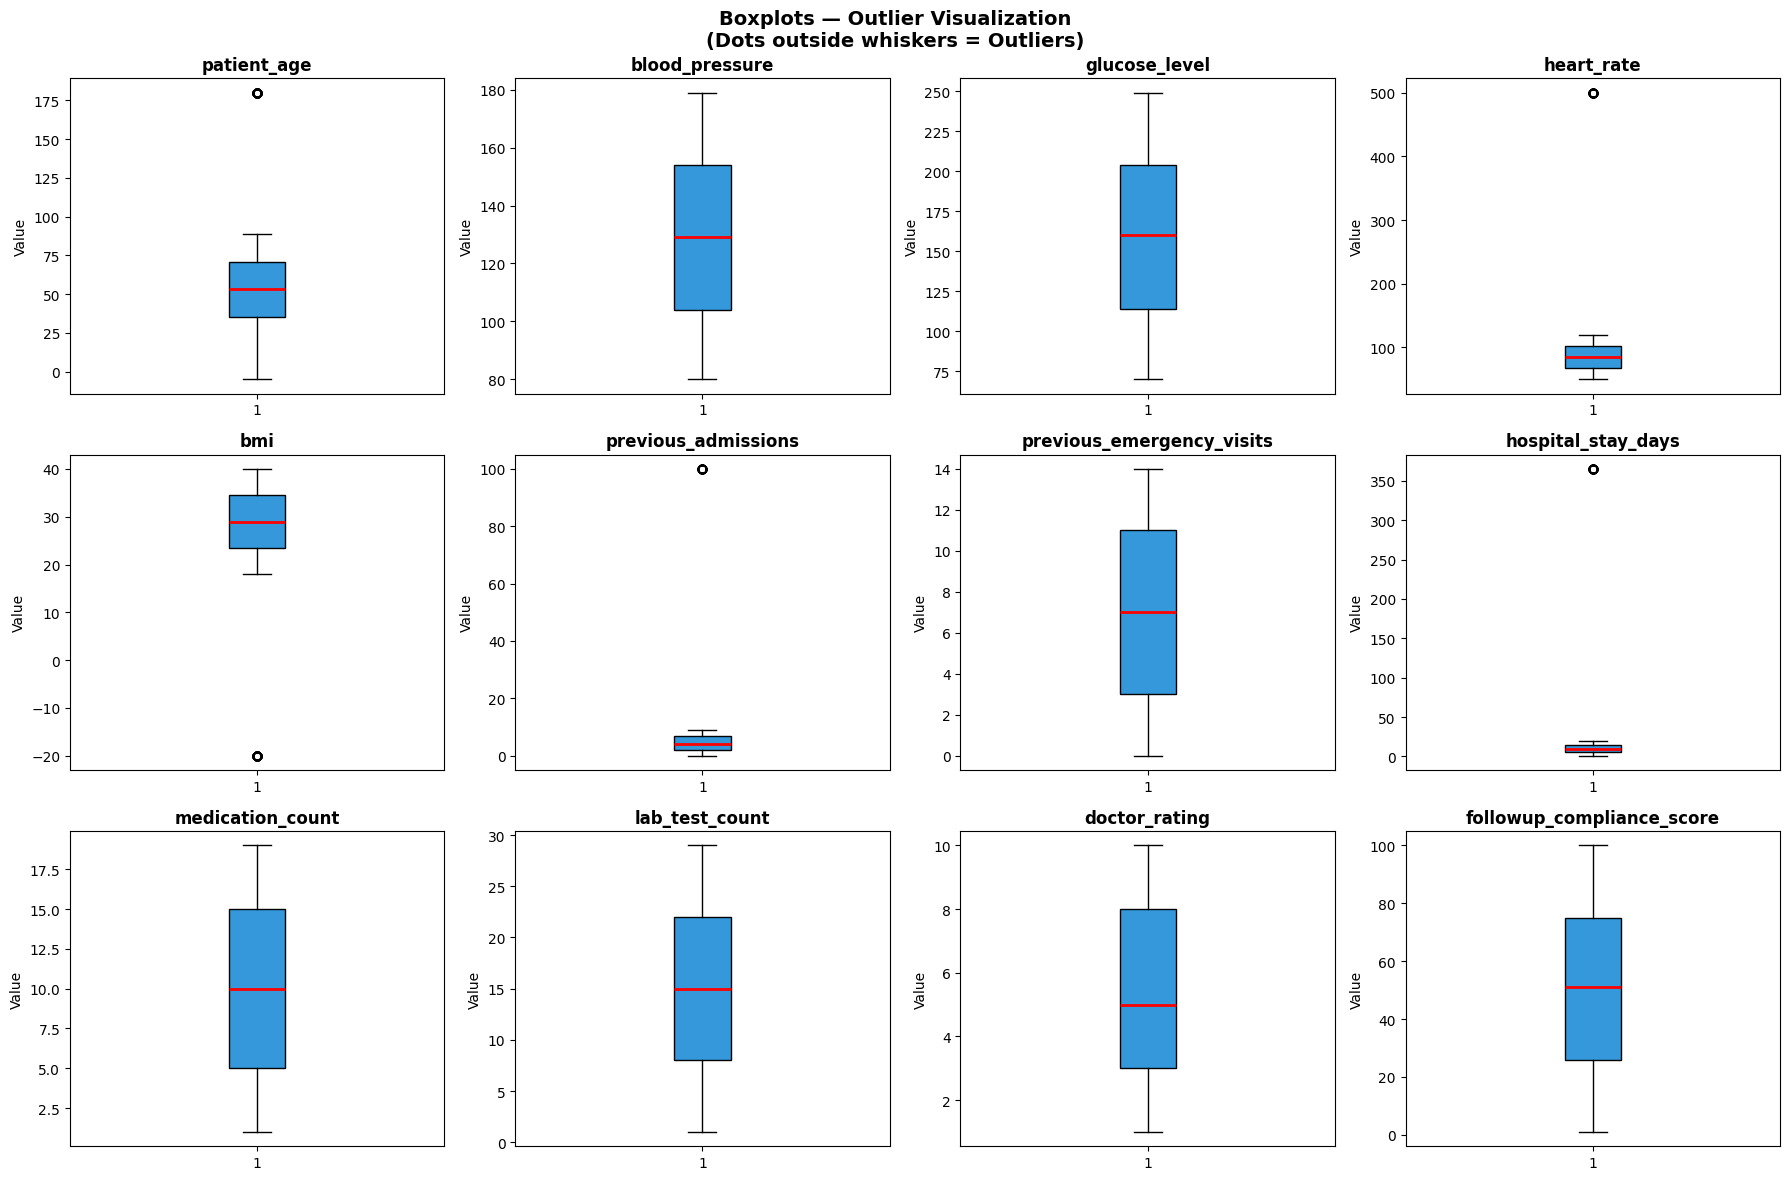

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', color='black'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — Outlier Visualization\n(Dots outside whiskers = Outliers)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\NG\Hospital Readmission Risk Prediction\reports\outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### Insights
- 7 out of 12 numerical columns are completely outlier-free by IQR — the dataset is relatively well-behaved for clinical data, which doesn't always hold at this scale.
- `patient_age` and `BMI` outliers at 0.2% each directly overlap with the invalid value flags caught earlier, meaning these are data errors worth correcting rather than genuine extreme clinical cases to preserve.
- `heart_rate`, `hospital_stay_days`, and `previous_admissions` each show ~0.1% outlier rates — low enough that capping at the IQR bounds is safer than dropping those rows, since removing them risks introducing bias.
- `blood_pressure` and `glucose_level` boxes are wide but fully whisker-contained, reflecting real clinical variability rather than errors — their ranges are medically plausible and should be left as-is.
- `doctor_rating` and `followup_compliance_score` show symmetric distributions with zero outliers, expected behavior for bounded score columns that have well-defined min/max limits.

\Data Type Verification

In [13]:
print("=" * 60)
print("       DATA TYPE VERIFICATION")
print("=" * 60)

expected_types = {
    'patient_id'               : 'string (ID — drop later)',
    'patient_age'              : 'int  ',
    'gender'                   : 'string   (needs cleaning)',
    'marital_status'           : 'string  ',
    'admission_type'           : 'string  ',
    'department'               : 'string  ',
    'diagnosis'                : 'string  ',
    'secondary_diagnosis'      : 'string  ',
    'blood_pressure'           : 'int  ',
    'glucose_level'            : 'float  ',
    'heart_rate'               : 'int  ',
    'bmi'                      : 'float  ',
    'previous_admissions'      : 'int  ',
    'previous_emergency_visits': 'int  ',
    'hospital_stay_days'       : 'int  ',
    'insurance_type'           : 'string  ',
    'medication_count'         : 'int  ',
    'lab_test_count'           : 'int ',
    'doctor_rating'            : 'float ',
    'followup_compliance_score': 'float ',
    'hospital_bill_amount'     : ' Should be float — stored as object (₹ symbol issue)',
    'admission_date'           : ' Should be datetime — stored as string',
    'discharge_date'           : ' Should be datetime — stored as string',
    'followup_date'            : '  Should be datetime — stored as string (mixed formats)',
    'readmission_notice_sent'  : ' LEAKAGE — will be dropped',
    'readmission_confirmed'    : ' LEAKAGE — will be dropped',
    'final_readmission_reason' : ' LEAKAGE — will be dropped',
    'readmitted'               : 'int  (Target Variable)'
}

print(f"\n{'Column':<30} {'Actual Type':<15} {'Expected/Notes'}")
print("-" * 80)
for col, note in expected_types.items():
    actual = str(df[col].dtype)
    print(f"{col:<30} {actual:<15} {note}")

       DATA TYPE VERIFICATION

Column                         Actual Type     Expected/Notes
--------------------------------------------------------------------------------
patient_id                     str             string (ID — drop later)
patient_age                    int64           int  
gender                         str             string   (needs cleaning)
marital_status                 str             string  
admission_type                 str             string  
department                     str             string  
diagnosis                      str             string  
secondary_diagnosis            str             string  
blood_pressure                 int64           int  
glucose_level                  float64         float  
heart_rate                     int64           int  
bmi                            float64         float  
previous_admissions            int64           int  
previous_emergency_visits      int64           int  
hospital_stay_days        

### Insights
- 16 of 28 columns are already in the correct numeric dtype — the core clinical measurements came through cleanly and won't need any type conversion work.
- All 4 type mismatches (`hospital_bill_amount` + the 3 date columns) trace directly back to format issues identified in earlier sections — resolving those format problems upstream will fix the dtypes as a side effect.
- The 3 leakage columns (`readmission_notice_sent`, `readmission_confirmed`, `final_readmission_reason`) are correctly stored as strings but must be dropped entirely before feature engineering — no amount of encoding or imputation makes them safe to include.
- `readmitted` is already `int64` with 0/1 values, confirming it's model-ready as the binary target variable with no further encoding needed.
- `patient_id` is correctly typed as a string but will be dropped before modeling — it's a row identifier with no predictive signal, and keeping it risks the model memorizing patient-level patterns.

\Complete Data Quality Report

In [15]:
print("=" * 60)
print("       COMPLETE DATA QUALITY REPORT")
print("=" * 60)

report = """
╔══════════════════════════════════════════════════════════════╗
║         HOSPITAL READMISSION — DATA QUALITY REPORT          ║
╚══════════════════════════════════════════════════════════════╝

DATASET: hospital_readmission_dataset.csv
ROWS   : 50,500 | COLUMNS: 28

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ISSUE 1: MISSING VALUES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Column                    | Missing % | Strategy (Step 3)
--------------------------+-----------+---------------------------
secondary_diagnosis       | 25.18%    | Fill with 'None'
glucose_level             | 15.01%    | Median imputation
doctor_rating             | 15.01%    | Median imputation
followup_compliance_score | 14.94%    | Median imputation
hospital_bill_amount      | 12.87%    | Median imputation
final_readmission_reason  | 19.79%    | DROP (leakage column)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ISSUE 2: DUPLICATE RECORDS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
→ Check result will appear after Cell 3 runs

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ISSUE 3: INCONSISTENT CATEGORIES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Column  | Problem                       | Fix
--------+-------------------------------+------------------
gender  | Male/male/M/MALE/Female/      | Standardize to
        | female/F/FEMALE               | 'Male' / 'Female'

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ISSUE 4: MIXED DATA FORMATS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Column               | Problem                    | Fix
---------------------+----------------------------+------------------
hospital_bill_amount | ₹125345 vs 26391.0         | Strip ₹, convert
followup_date        | YYYY-MM-DD vs MM-DD-YYYY   | Unified parsing

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ISSUE 5: DATA LEAKAGE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Column                   | Why Leakage
-------------------------+----------------------------------------
readmission_notice_sent  | Sent only after readmission happens
readmission_confirmed    | IS the event we are predicting
final_readmission_reason | Known only after readmission

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ISSUE 6: CLASS IMBALANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Readmitted (1)     : 47,250 → 93.6%
Not Readmitted (0) :  3,250 →  6.4%
Fix                : SMOTE oversampling + class_weight

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ISSUE 7: DATA TYPE MISMATCHES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
hospital_bill_amount : object → float
admission_date       : object → datetime
discharge_date       : object → datetime
followup_date        : object → datetime
"""

print(report)

# Save to file
with open(r'C:\NG\Hospital Readmission Risk Prediction\reports\02_data_quality_report.txt', 'w',encoding='utf-8') as f:
    f.write(report)

print(" Data Quality Report saved to reports/02_data_quality_report.txt")

       COMPLETE DATA QUALITY REPORT

╔══════════════════════════════════════════════════════════════╗
║         HOSPITAL READMISSION — DATA QUALITY REPORT          ║
╚══════════════════════════════════════════════════════════════╝

DATASET: hospital_readmission_dataset.csv
ROWS   : 50,500 | COLUMNS: 28

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ISSUE 1: MISSING VALUES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Column                    | Missing % | Strategy (Step 3)
--------------------------+-----------+---------------------------
secondary_diagnosis       | 25.18%    | Fill with 'None'
glucose_level             | 15.01%    | Median imputation
doctor_rating             | 15.01%    | Median imputation
followup_compliance_score | 14.94%    | Median imputation
hospital_bill_amount      | 12.87%    | Median imputation
final_readmission_reason  | 19.79%    | DROP (leakage column)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ISSUE 2: DUPLICATE RECORDS
━━━━━━━━━━━━━━